# Klasyfikacja danych niezrównoważonych - aplikacja randkowa "Habibi"

Celem jest przewidywanie "matcha" w zbiorze *Speed Dating*. Klasa pozytywna
(match) jest rzadka (~16%), więc cała trudność polega na pracy z danymi
niezbalansowanymi.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, precision_score, recall_score,
                             f1_score, confusion_matrix, fbeta_score)
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1.1: Pobranie danych i EDA

In [2]:
data = fetch_openml(data_id=40536, as_frame=True)
df = data.frame
print("Wymiary zbioru:", df.shape)
print("Rozkład klasy match:")
print(df['match'].value_counts())
print("Udział klasy pozytywnej:", round(df['match'].astype(int).mean(), 4))

Wymiary zbioru: (8378, 121)
Rozkład klasy match:
match
0    6998
1    1380
Name: count, dtype: int64
Udział klasy pozytywnej: 0.1647


In [3]:
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1


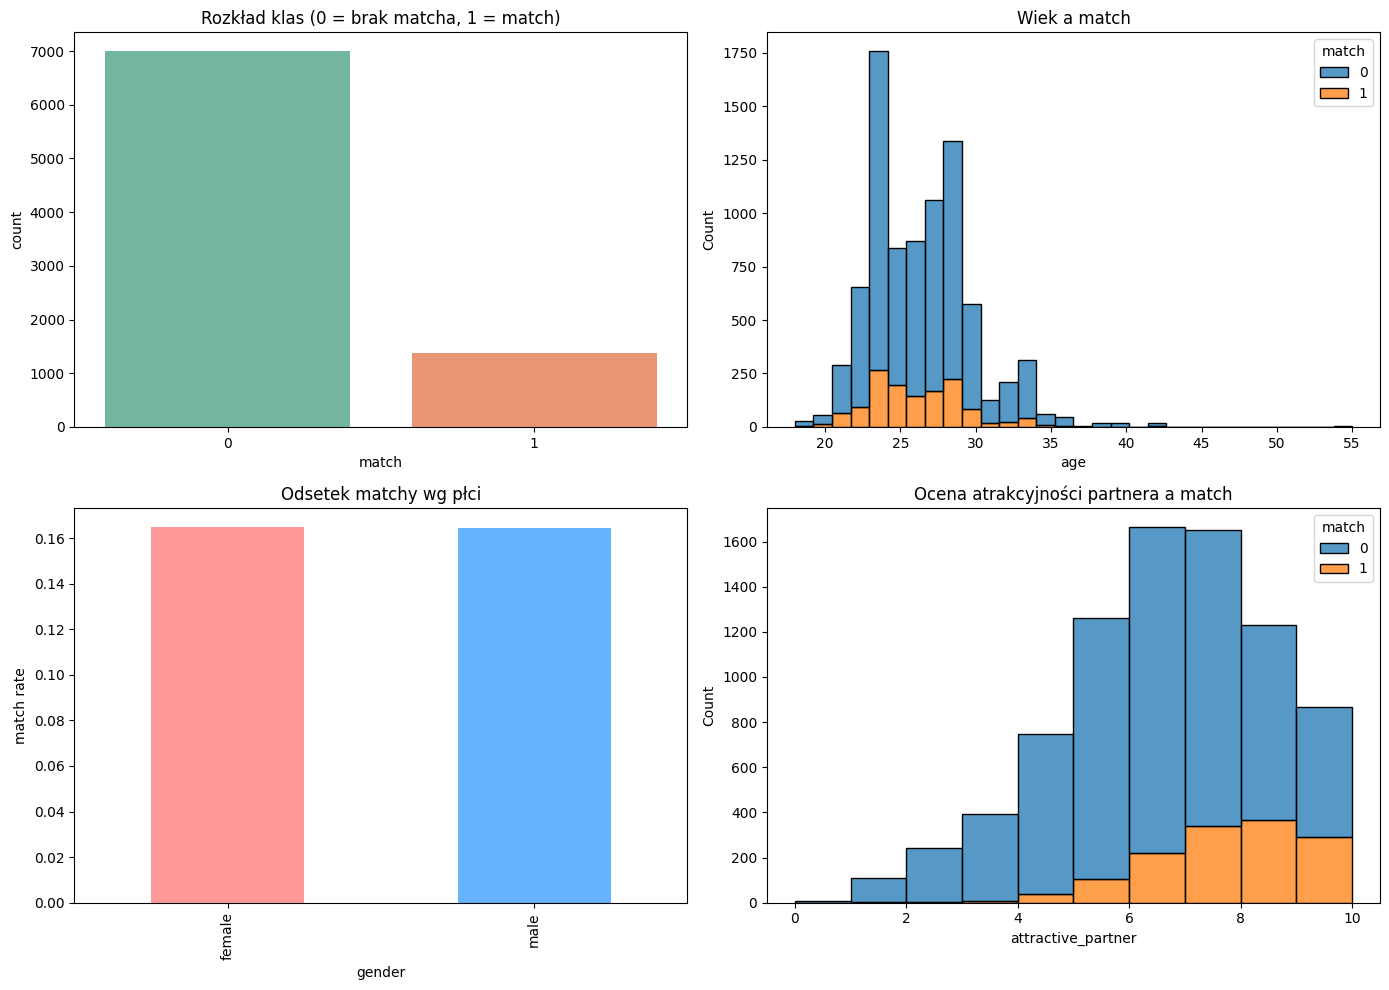

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='match', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Rozkład klas (0 = brak matcha, 1 = match)')

sns.histplot(data=df, x='age', hue='match', bins=30, ax=axes[0, 1], multiple='stack')
axes[0, 1].set_title('Wiek a match')

match_by_gender = df.groupby('gender')['match'].apply(lambda s: s.astype(int).mean())
match_by_gender.plot(kind='bar', ax=axes[1, 0], color=['#ff9999', '#66b3ff'])
axes[1, 0].set_title('Odsetek matchy wg płci')
axes[1, 0].set_ylabel('match rate')

sns.histplot(data=df, x='attractive_partner', hue='match', bins=10, ax=axes[1, 1], multiple='stack')
axes[1, 1].set_title('Ocena atrakcyjności partnera a match')

plt.tight_layout()
plt.show()

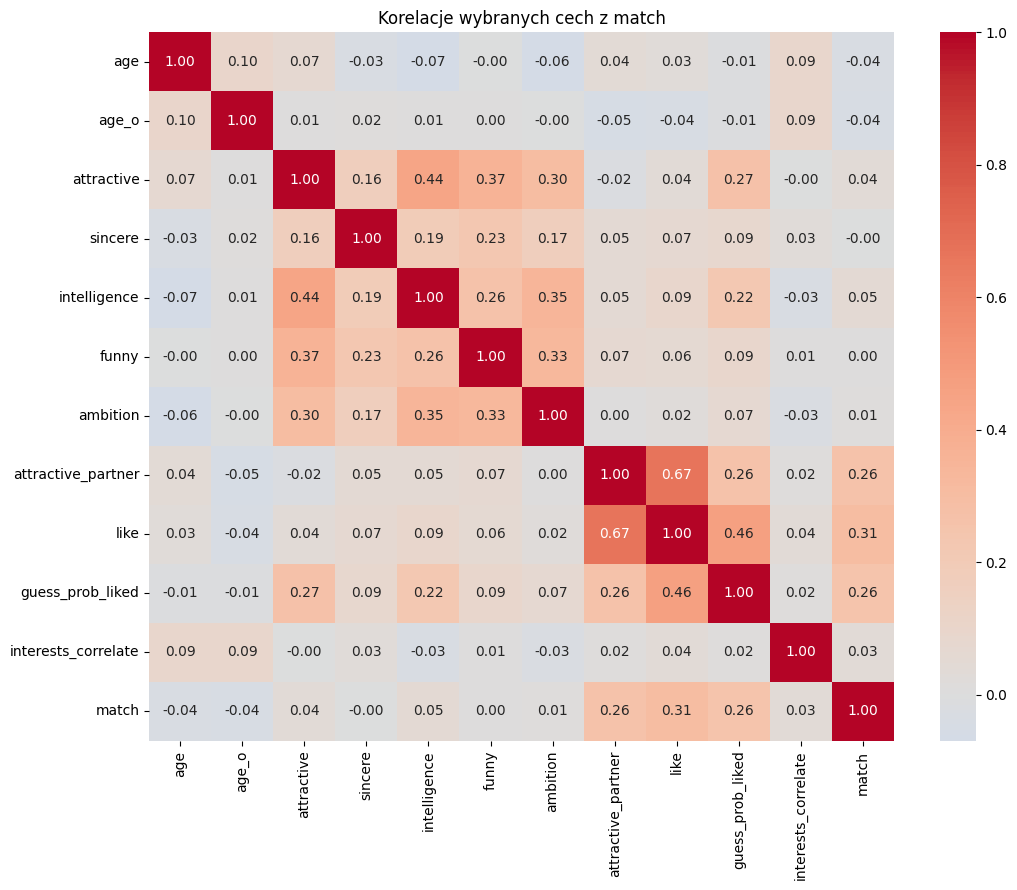

In [5]:
num_cols_eda = ['age', 'age_o', 'attractive', 'sincere', 'intelligence', 'funny',
                'ambition', 'attractive_partner', 'like', 'guess_prob_liked',
                'interests_correlate']
corr = df[num_cols_eda + []].assign(match=df['match'].astype(int)).corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelacje wybranych cech z match')
plt.tight_layout()
plt.show()

## 1.2: Przygotowanie danych

In [6]:
fingerprint_cols = ['gender', 'age', 'race', 'field',
                    'importance_same_race', 'importance_same_religion',
                    'attractive_important', 'sincere_important', 'intellicence_important',
                    'funny_important', 'ambtition_important', 'shared_interests_important',
                    'attractive', 'sincere', 'intelligence', 'funny', 'ambition',
                    'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking',
                    'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts',
                    'music', 'shopping', 'yoga']
user_id = df[fingerprint_cols].apply(lambda r: '|'.join(map(str, r.values)), axis=1)
print("Liczba unikalnych użytkowników:", user_id.nunique())
print("Średnia liczba interakcji na użytkownika:", round(user_id.value_counts().mean(), 2))

Liczba unikalnych użytkowników: 547
Średnia liczba interakcji na użytkownika: 15.32


In [7]:
leakage_cols = ['attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o',
                'shared_interests_o', 'attractive_partner', 'sincere_partner',
                'intelligence_partner', 'funny_partner', 'ambition_partner',
                'shared_interests_partner', 'like', 'guess_prob_liked', 'met',
                'decision', 'decision_o']
discretized_cols = [c for c in df.columns if c.startswith('d_')]
drop_cols = set(leakage_cols + discretized_cols + ['has_null', 'wave', 'field', 'match'])

y = df['match'].astype(int)
X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
print("Liczba cech po usunięciu wycieku:", X.shape[1])

Liczba cech po usunięciu wycieku: 46


In [8]:
X['age_gap'] = (X['age'] - X['age_o']).abs()
fit_pairs = [('attractive', 'pref_o_attractive'), ('sincere', 'pref_o_sincere'),
             ('intelligence', 'pref_o_intelligence'), ('funny', 'pref_o_funny'),
             ('ambition', 'pref_o_ambitious')]
for self_attr, partner_pref in fit_pairs:
    self_norm = (X[self_attr] - 1) / 9
    partner_norm = X[partner_pref] / 100
    X['deficit_' + self_attr] = (partner_norm - self_norm).clip(lower=0)

cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, dummy_na=False)
X = X.astype(float)
print("Liczba cech po inżynierii i kodowaniu:", X.shape[1])


Liczba cech po inżynierii i kodowaniu: 62


In [9]:
rng = np.random.RandomState(RANDOM_STATE)
unique_users = user_id.unique()
test_users = rng.choice(unique_users, size=int(len(unique_users) * 0.30), replace=False)
test_users = set(test_users)

test_index = []
for u in test_users:
    rows = user_id.index[user_id == u].to_numpy()
    test_index.extend(rng.choice(rows, size=5, replace=False))
test_index = np.array(test_index)
train_index = user_id.index[~user_id.isin(test_users)].to_numpy()

X_train, X_test = X.loc[train_index], X.loc[test_index]
y_train, y_test = y.loc[train_index], y.loc[test_index]
test_user_id = user_id.loc[test_index]

print("Trening:", X_train.shape, "match rate:", round(y_train.mean(), 3))
print("Test:   ", X_test.shape, "match rate:", round(y_test.mean(), 3))
print("Użytkownicy w teście:", len(test_users), "każdy po 5 prób ->", len(test_index), "wierszy")

Trening: (5844, 62) match rate: 0.157
Test:    (820, 62) match rate: 0.171
Użytkownicy w teście: 164 każdy po 5 prób -> 820 wierszy


## 1.3: Model bazowy i wizualizacja problemu

In [10]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_train_p = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_p = scaler.transform(imputer.transform(X_test))
feature_names = X_train.columns.to_numpy()

In [11]:
dummy_major = DummyClassifier(strategy='most_frequent')
dummy_random = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_major.fit(X_train_p, y_train)
dummy_random.fit(X_train_p, y_train)

print("=== Predyktor większościowy ===")
print(classification_report_imbalanced(y_test, dummy_major.predict(X_test_p)))
print("=== Predyktor losowy ===")
print(classification_report_imbalanced(y_test, dummy_random.predict(X_test_p)))

=== Predyktor większościowy ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      1.00      0.00      0.91      0.00      0.00       680
          1       0.00      0.00      1.00      0.00      0.00      0.00       140

avg / total       0.69      0.83      0.17      0.75      0.00      0.00       820

=== Predyktor losowy ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.84      0.18      0.83      0.39      0.16       680
          1       0.18      0.18      0.84      0.18      0.39      0.14       140

avg / total       0.72      0.72      0.29      0.72      0.39      0.16       820



In [12]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train_p, y_train)
print("=== Regresja logistyczna (bez ważenia klas) ===")
print(classification_report_imbalanced(y_test, baseline.predict(X_test_p)))

=== Regresja logistyczna (bez ważenia klas) ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      1.00      0.01      0.91      0.12      0.02       680
          1       0.50      0.01      1.00      0.03      0.12      0.01       140

avg / total       0.77      0.83      0.18      0.76      0.12      0.02       820



## 1.4: resampling

In [13]:
sub_idx = rng.choice(np.arange(len(X_train_p)), size=1500, replace=False)
X_sub = X_train_p[sub_idx]
y_sub = y_train.to_numpy()[sub_idx]

smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_sub, y_sub)

under_over = ImbPipeline([
    ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE)),
    ('over', SMOTE(random_state=RANDOM_STATE))
])
X_uo, y_uo = under_over.fit_resample(X_sub, y_sub)

smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_enn, y_enn = smote_enn.fit_resample(X_sub, y_sub)

print("Oryginał:", np.bincount(y_sub))
print("SMOTE:", np.bincount(y_smote))
print("Under+SMOTE:", np.bincount(y_uo))
print("SMOTE+ENN:", np.bincount(y_enn))

Oryginał: [1281  219]
SMOTE: [1281 1281]
Under+SMOTE: [438 438]
SMOTE+ENN: [ 729 1208]


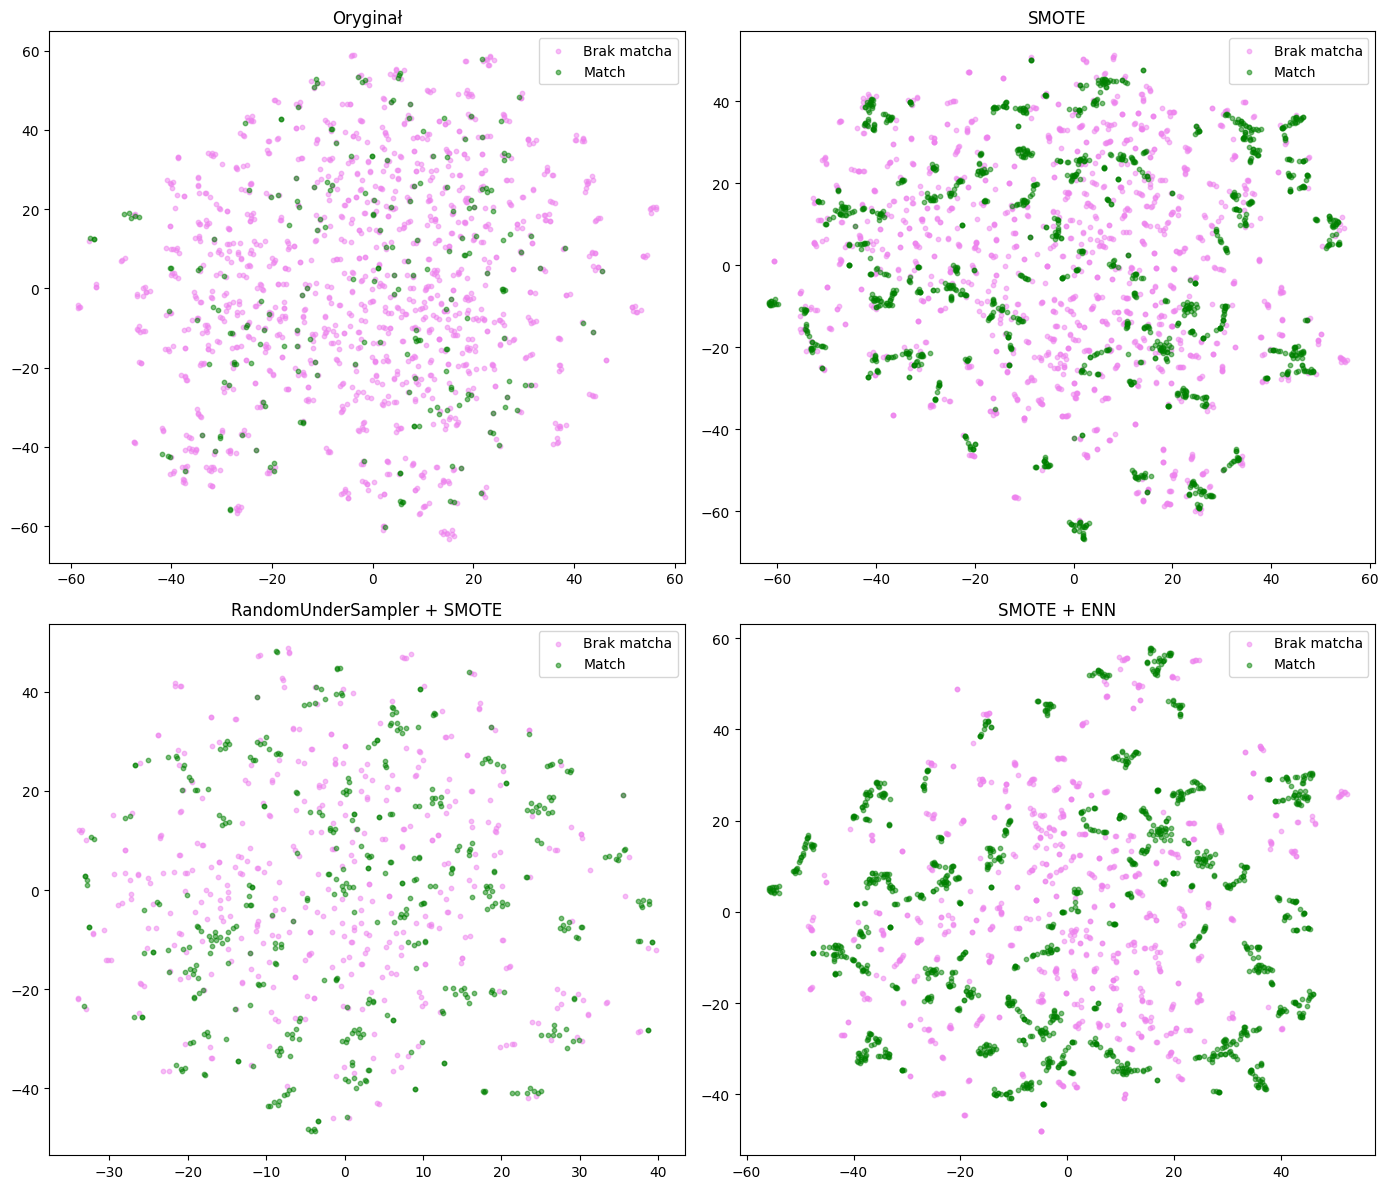

In [14]:
def tsne_2d(data):
    return TSNE(n_components=2, random_state=RANDOM_STATE, init='pca',
                learning_rate='auto').fit_transform(data)

sets = [('Oryginał', X_sub, y_sub), ('SMOTE', X_smote, y_smote),
        ('RandomUnderSampler + SMOTE', X_uo, y_uo), ('SMOTE + ENN', X_enn, y_enn)]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (title, data, labels) in zip(axes.ravel(), sets):
    emb = tsne_2d(data)
    ax.scatter(emb[labels == 0, 0], emb[labels == 0, 1], s=10, c='violet', alpha=0.5, label='Brak matcha')
    ax.scatter(emb[labels == 1, 0], emb[labels == 1, 1], s=10, c='green', alpha=0.5, label='Match')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## 1.5: Modele ensemble dla danych niezbalansowanych

In [15]:
models = {}

lr_w = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_w.fit(X_train_p, y_train)
models['LogReg (class_weight)'] = lr_w

rf_w = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                              random_state=RANDOM_STATE, n_jobs=-1)
rf_w.fit(X_train_p, y_train)
models['RandomForest (class_weight)'] = rf_w

brf = BalancedRandomForestClassifier(n_estimators=300, sampling_strategy='all',
                                     replacement=True, bootstrap=False,
                                     random_state=RANDOM_STATE, n_jobs=-1)
brf.fit(X_train_p, y_train)
models['BalancedRandomForest'] = brf

eec = EasyEnsembleClassifier(n_estimators=10, random_state=RANDOM_STATE)
eec.fit(X_train_p, y_train)
models['EasyEnsemble'] = eec

smote_lr = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)),
                        ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
smote_lr.fit(X_train_p, y_train)
models['SMOTE + LogReg'] = smote_lr

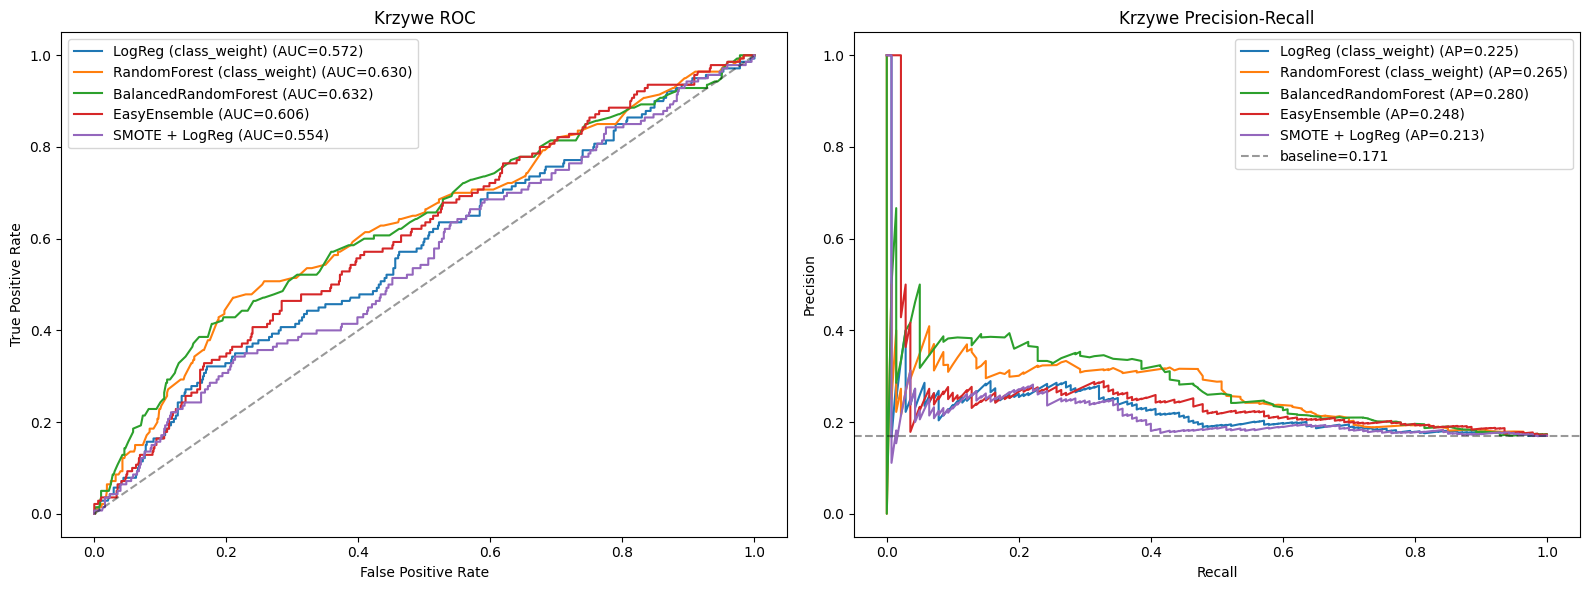

In [16]:
results = {}
for name, model in models.items():
    proba = model.predict_proba(X_test_p)[:, 1]
    results[name] = {'proba': proba,
                     'auc': roc_auc_score(y_test, proba),
                     'ap': average_precision_score(y_test, proba)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, r['proba'])
    axes[1].plot(rec, prec, label=f"{name} (AP={r['ap']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Krzywe ROC'); axes[0].legend()

axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.4, label=f'baseline={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Krzywe Precision-Recall'); axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
summary15 = pd.DataFrame({n: {'ROC AUC': r['auc'], 'Average Precision': r['ap']}
                          for n, r in results.items()}).T.sort_values('Average Precision', ascending=False)
summary15.round(3)

,ROC AUC,Average Precision
BalancedRandomForest,0.632,0.280
RandomForest (class_weight),0.630,0.265
EasyEnsemble,0.606,0.248
LogReg (class_weight),0.572,0.225
SMOTE + LogReg,0.554,0.213


# CZĘŚĆ 2 Kalibracja modeli i macierz kosztów

Najlepszy model wg AP: BalancedRandomForest


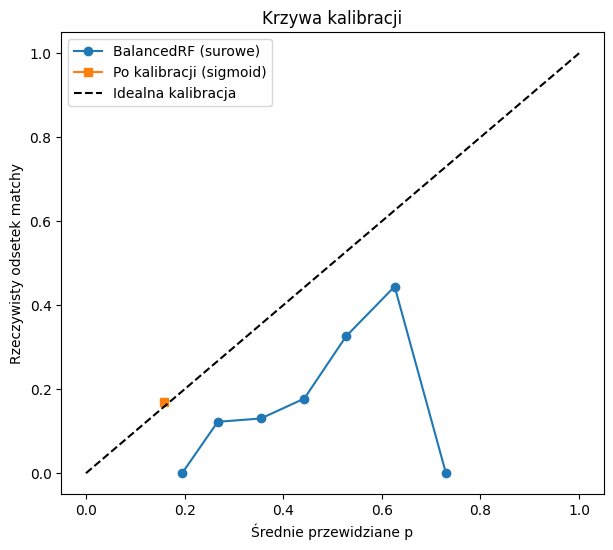

In [ ]:
best_name = summary15.index[0]
print("Najlepszy model wg AP:", best_name)

best_model = models[best_name]
proba_test = best_model.predict_proba(X_test_p)[:, 1]

calibrated = CalibratedClassifierCV(BalancedRandomForestClassifier(
    n_estimators=300, sampling_strategy='all', replacement=True, bootstrap=False,
    random_state=RANDOM_STATE, n_jobs=-1), method='sigmoid', cv=5)
calibrated.fit(X_train_p, y_train)
proba_cal = calibrated.predict_proba(X_test_p)[:, 1]

fp_raw, mp_raw = calibration_curve(y_test, proba_test, n_bins=10)
fp_cal, mp_cal = calibration_curve(y_test, proba_cal, n_bins=10)
plt.figure(figsize=(7, 6))
plt.plot(mp_raw, fp_raw, 'o-', label='BalancedRF (surowe)')
plt.plot(mp_cal, fp_cal, 's-', label='Po kalibracji (sigmoid)')
plt.plot([0, 1], [0, 1], 'k--', label='Idealna kalibracja')
plt.xlabel('Średnie przewidziane p'); plt.ylabel('Rzeczywisty odsetek matchy')
plt.title('Krzywa kalibracji'); plt.legend()
plt.show()

## 2.1: precision@K, MRR

In [ ]:
def ranking_metrics(user_ids, y_true, scores, k=3):
    rec_df = pd.DataFrame({'user': user_ids.values, 'y': y_true.values, 'score': scores})
    precisions, rrs = [], []
    for _, group in rec_df.groupby('user'):
        ordered = group.sort_values('score', ascending=False)['y'].to_numpy()
        if ordered.sum() == 0:
            continue
        precisions.append(ordered[:k].sum() / k)
        first = np.argmax(ordered == 1) + 1
        rrs.append(1.0 / first)
    return np.mean(precisions), np.mean(rrs)

p_at_k, mrr = ranking_metrics(test_user_id, y_test, proba_test, k=3)
print(f"Mean Precision@3: {p_at_k * 100:.2f}%")
print(f"Mean Reciprocal Rank (MRR): {mrr:.3f}")

Mean Precision@3: 35.82%
Mean Reciprocal Rank (MRR): 0.677


## 2.2: Model romantyczny

In [ ]:
thresholds = np.linspace(0.01, 0.99, 99)
fbeta_scores = [fbeta_score(y_test, (proba_test >= t).astype(int), beta=3, zero_division=0)
                for t in thresholds]
romantic_threshold = thresholds[int(np.argmax(fbeta_scores))]
print("Próg modelu romantycznego:", round(romantic_threshold, 3))

y_romantic = (proba_test >= romantic_threshold).astype(int)
print("Recall:", round(recall_score(y_test, y_romantic), 3))
print("Precision:", round(precision_score(y_test, y_romantic, zero_division=0), 3))

Próg modelu romantycznego: 0.23
Recall: 1.0
Precision: 0.174


## 2.3: Model biznesowy

Próg modelu biznesowego: 0.58


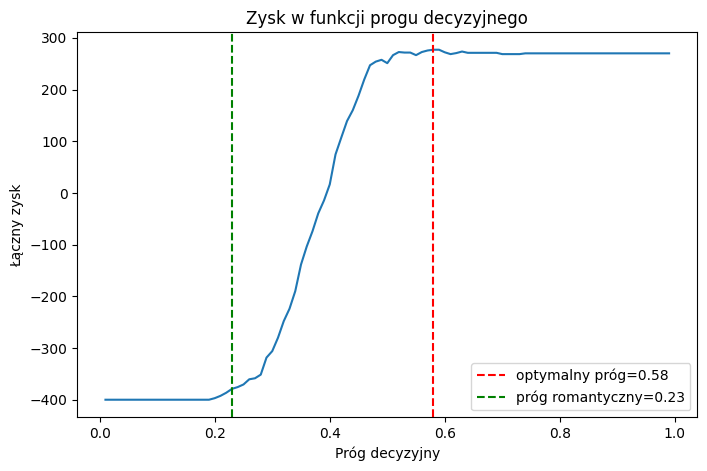

In [ ]:
COST = {'TP': 2.0, 'TN': 0.5, 'FP': -1.0, 'FN': -0.5}

def total_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp * COST['TP'] + tn * COST['TN'] + fp * COST['FP'] + fn * COST['FN']

profits = [total_profit(y_test, (proba_test >= t).astype(int)) for t in thresholds]
business_threshold = thresholds[int(np.argmax(profits))]
print("Próg modelu biznesowego:", round(business_threshold, 3))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, profits)
plt.axvline(business_threshold, color='red', ls='--', label=f'optymalny próg={business_threshold:.2f}')
plt.axvline(romantic_threshold, color='green', ls='--', label=f'próg romantyczny={romantic_threshold:.2f}')
plt.xlabel('Próg decyzyjny'); plt.ylabel('Łączny zysk')
plt.title('Zysk w funkcji progu decyzyjnego'); plt.legend()
plt.show()

## 2.4: Podsumowanie wyników

In [ ]:
def evaluate(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {'Próg': round(threshold, 3),
            'Precision': round(precision_score(y_true, pred, zero_division=0), 3),
            'Recall': round(recall_score(y_true, pred), 3),
            'F1': round(f1_score(y_true, pred, zero_division=0), 3),
            'Zysk': round(total_profit(y_true, pred), 1)}

comparison = pd.DataFrame({
    'Model romantyczny': evaluate(y_test, proba_test, romantic_threshold),
    'Model biznesowy': evaluate(y_test, proba_test, business_threshold)
}).T
comparison

,Próg,Precision,Recall,F1,Zysk
Model romantyczny,0.23,0.174,1.00,0.296,-379.0
Model biznesowy,0.58,0.500,0.05,0.091,277.0


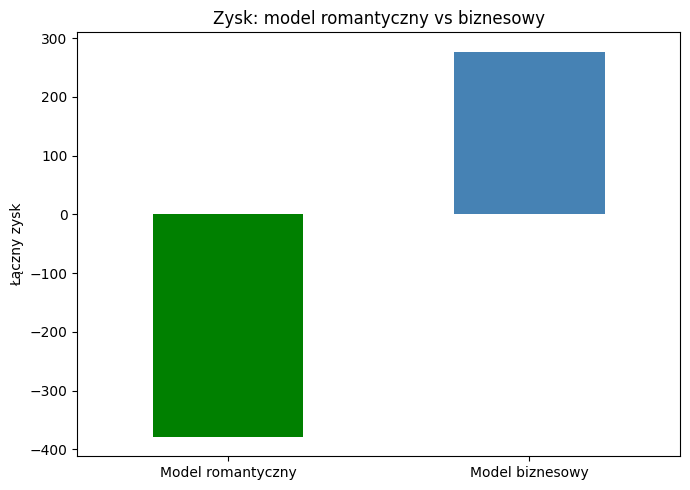

In [ ]:
comparison['Zysk'].plot(kind='bar', color=['green', 'steelblue'], figsize=(7, 5))
plt.title('Zysk: model romantyczny vs biznesowy')
plt.ylabel('Łączny zysk')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()